# DS3000 Final Project: Finding the Best Bet
### Team 67 
* Ethan Gu
* Reuben Houghton


## Executive Summary:
After testing with regular season NBA game data, we wanted to investigate NBA playoff games to observe if there were superior/safer betting sites and also better games to bet on during the playoffs (based on a few features such as amount of wins during the regular season, pregame probabilities to win, and the odds provided by betting sites). We did this by collecting NBA playoff game betting odds from 20 different betting sites through The Odds API (cited a little later). Our comparison between betting sites utilized expected value for a $100 bet considering the odds provided by each individual betting site and the pre-game probabilities for either side to win. We also utilized KMeans Clustering with the betting odds, regular season wins, and some more features to find similarities among the games and betting odds across our dataset. Overall, we were able to see certain betting sites like BetFair and BetUS perform far better than others like FOXBet. On the other hand, our clusters were not able to consistently predict winners, likely due to other variables like star player injuries, travel between games, fatigue, etc.

## Introduction

Finding the best site to bet on is a time-consuming and challenging task. With odds constantly changing, finding what betting site is giving you the best odds manually is nearly impossible. Preventing consumers from being able to maximize their potential profits and minimize their potential losses, instead settling for larger name betting sites that may not even be providing the best odds for any sporting event on any given day. We want to look at the sports betting odds provided by multiple betting sites for NBA games to see if there is a noticeable difference or a preferable betting site over larger names like FanDuel and DraftKings.


Initially, our objective was to create a web-scraping algorithm to scrape odds from different betting sites in order to obtain our information. We quickly realized that this process would be too difficult since 
1. betting sites encrypt their data when you inspect their page to prevent web scraping and... 
2. if we were to manage to webscrape a betting site, many betting sites update their encryptions periodically which could prove to be another problem down the road. 
3. After webscraping one site, we realized that it did not yield all the information we wanted to analyze

Instead, we found a sports betting API (the-odds-api) that compiles the moneyline and spread odds from multiple sports betting sites. 

We wanted to focus on playoff games, since there is much more competition and a need to win games. Due to the limited number of playoff games per day, we want to create a pipeline that cleans the data we retrieve as a json into a more readable nested dictionary then as a pandas dataframe. , which we will then use for our visualizations and analysis. 

## Data Description

In [1]:
import requests
import pandas as pd
from bs4 import BeautifulSoup
import json

#Source: https://the-odds-api.com/
url = f'https://api.the-odds-api.com/v4/sports/basketball_nba/odds/?apiKey=eaa265db381b34b1dbe2ce35e2628048&regions=us&markets=h2h,spreads&oddsFormat=american'
#betting_text = requests.get(url).text
#betting_data = json.loads(betting_text)

We used The Odds API
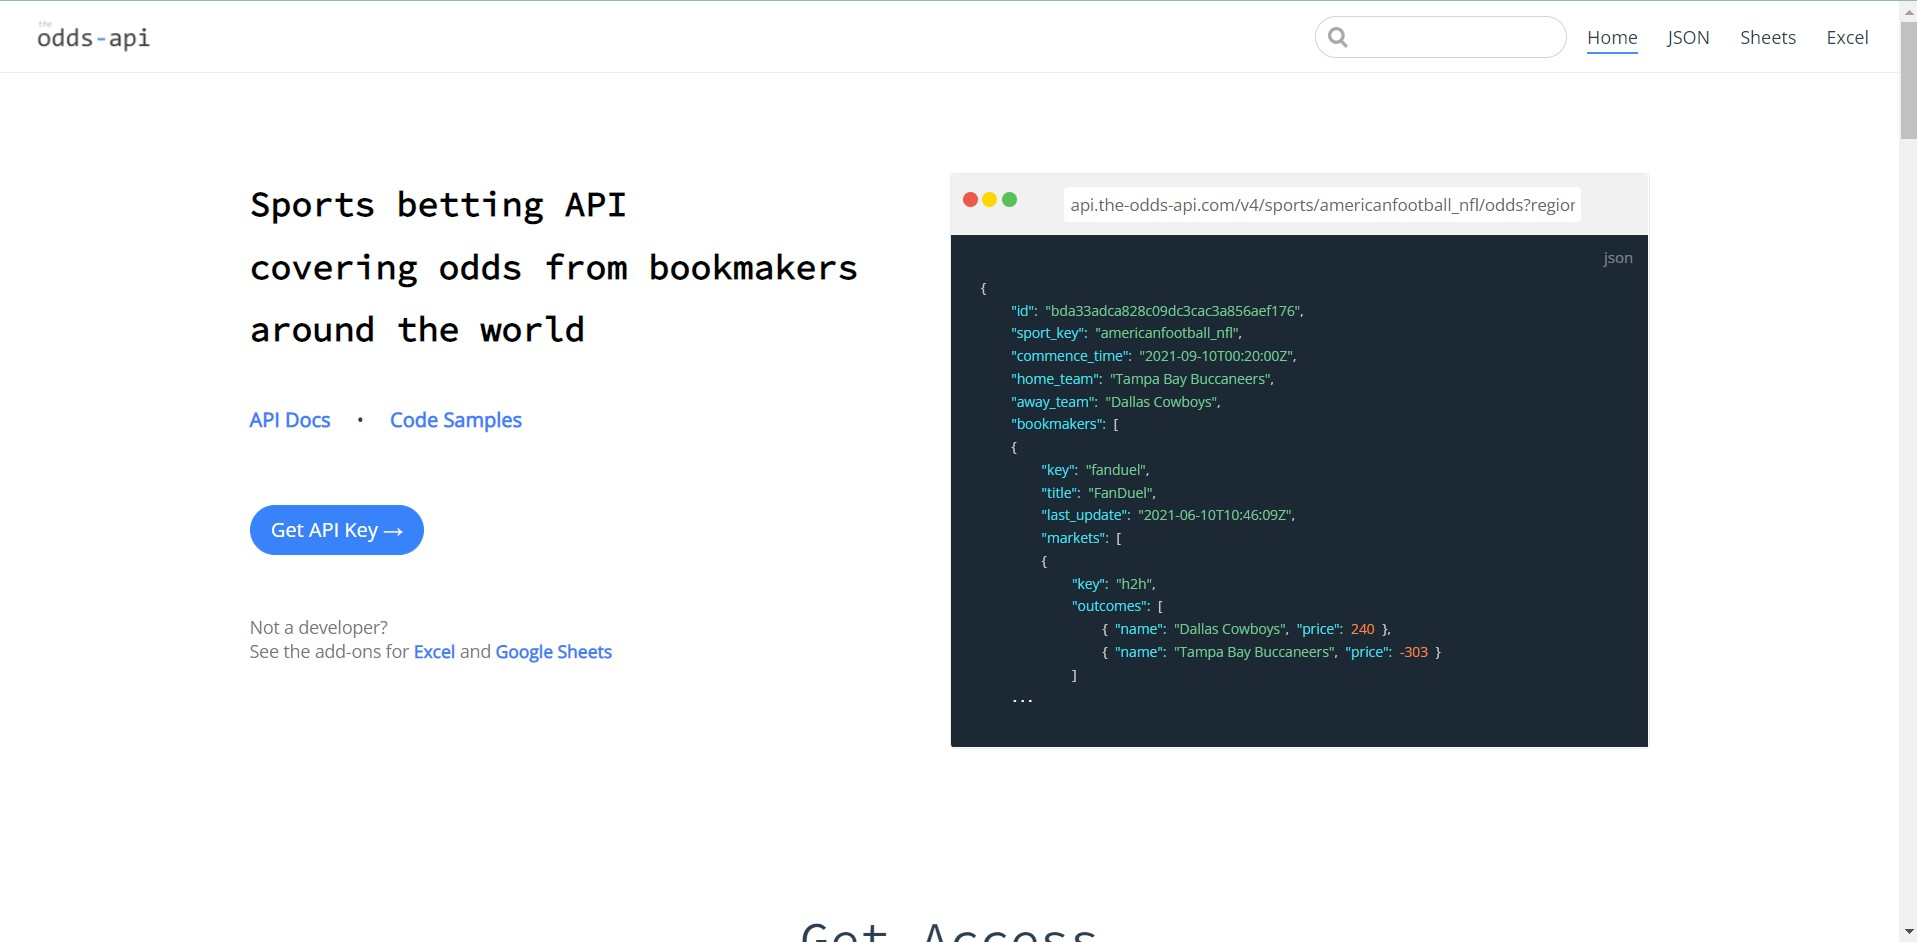

Through our API calls, there are mnay customizable parameters with the relevant ones being 
1. sport - NBA Basketball in our case
2. regions - US
3. markets - h2h/moneyline
4. oddsFormat - American
5. daysFrom - was altered a few times, but allows an API call to get betting odds from multiple days at once


In [2]:
# get the sites that the API stores data from
sites_list = list()
for game in betting_data:
    bookmakers = game['bookmakers']
    for site in bookmakers:
        sites_list.append(site['title'])
        
sites_list = list(set(sites_list))

NameError: name 'betting_data' is not defined

In [ ]:
#init a dictionary so that we get our first look at the data
data_by_game = dict()

for game in betting_data:
    # Get the home team and away team by game and format it for easier viewing
    
    home = game['home_team']
    away = game['away_team']
    
    matchup = f'{away} @ {home}'
    
    # Keep the matchup name as the key, will store odds by site as value
    data_by_game[matchup] = dict()
    
    bookmakers = game['bookmakers']
    for site in bookmakers:
        site_title = site['title']
        data_by_game[matchup][site_title] = dict()
        markets = site['markets']
        
        for market in markets:
            bet_format = market['key']
            data_by_game[matchup][site_title][bet_format] = market['outcomes']
                     
#import pretty printer
import pprint
#this library helps us see all of the nested dictionaries 
pp = pprint.PrettyPrinter(indent=4)
pp.pprint(data_by_game)

## Build DataFrame

Through the indexing into our nested dictionary, we extracted the values we wanted to produce csv files like this one below:
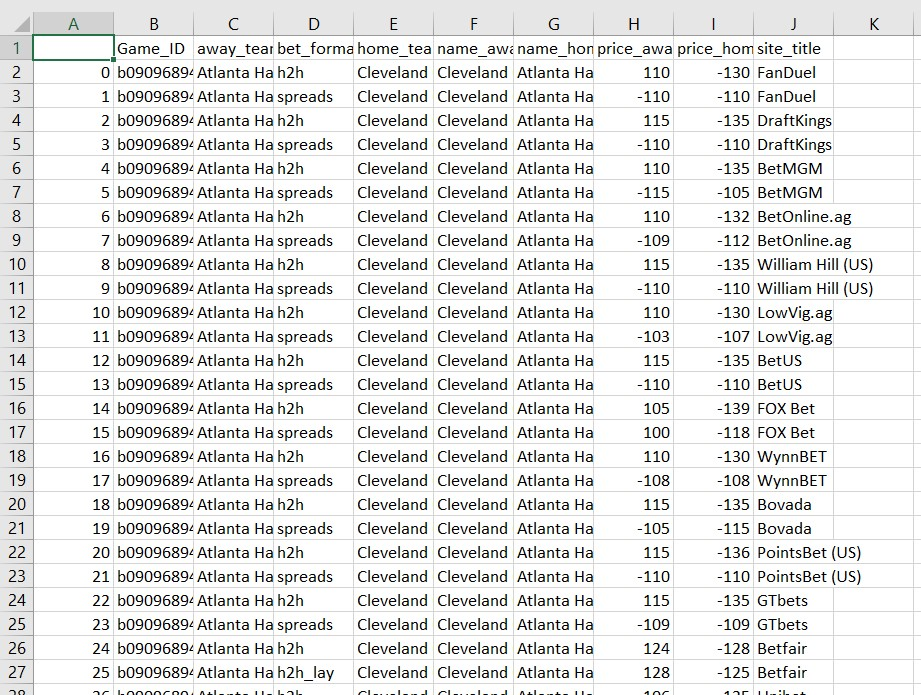

For each csv, we can obtain the following information for each game on a given day:
* Game ID
* Home and Away team
* Bet Format
* The betting odds for the home and away team
* The name of the betting site

As we'll see in future steps, we will use even more data not included in our API calls for our analyses including regular season wins, win probabilities, and expected value for a bet that will continue to add onto the existing dataframe

In [ ]:
# init dataframe
df_bets = pd.DataFrame()

for game in betting_data:
    # Get the home team and away team by game and format it for easier viewing
    
    team_home = game['home_team']
    team_away = game['away_team']
    Game_ID = game['id']
    
    bookmakers = game['bookmakers']
    
    for site in bookmakers:
        site_title = site['title']
        #data_by_game[matchup][site_title] = dict()
        markets = site['markets']
        
             
        for market in markets:
            bet_format = market['key']
            bet = market['outcomes']
            
            
            # create a dictionary and add all of the required items to it 
            bet_dict = {}
            bet_dict['Game_ID'] = Game_ID
            bet_dict['bet_format'] = market['key']
            
            if bet_format == 'spreads':
                bet_dict['point_spread_away'] = bet[0]['point']
                bet_dict['point_spread_home'] = bet[1]['point']
            else:
                bet_dict['point_spread_away'] = 0
                bet_dict['point_spread_home'] = 0
            
            bet_dict['site_title'] = site_title
            bet_dict['home_team'] = team_home
            bet_dict['away_team'] = team_away
            
            bet_dict['price_away'] = bet[0]['price']
            bet_dict['price_home'] = bet[1]['price']
            
            df_bets = df_bets.append(bet_dict, ignore_index = True)
            
            
     
# How we stored games from different days, since the API only holds three days worth of games per call
# df_bets.to_csv('25April.csv')

## Merge the Data we saved in csv files into a DataFrame
Since we needed to pull data from NBA games on multiple days, we would save checkpoints as separate csv files, which we need to merge all together in order to complete a complete analysis over all of our data. We plan to continue append more and more games to our dataframe in the future, to get a better perspective for our project objective.

In [46]:
import pandas as pd

data = pd.read_csv('18-21April.csv')

In [48]:
h2h_data = data[data['bet_format']=='h2h']
del h2h_data['point_spread_away']
del h2h_data['point_spread_home']
h2h_data

,Unnamed: 0,Game_ID,away_team,bet_format,home_team,price_away,price_home,site_title
0,0,2647c9e2bee2448aff8cd9f719e18227,Memphis Grizzlies,h2h,Minnesota Timberwolves,-135.0,115.0,BetOnline.ag
2,2,2647c9e2bee2448aff8cd9f719e18227,Memphis Grizzlies,h2h,Minnesota Timberwolves,-132.0,112.0,FanDuel
4,4,2647c9e2bee2448aff8cd9f719e18227,Memphis Grizzlies,h2h,Minnesota Timberwolves,-130.0,110.0,DraftKings
6,6,2647c9e2bee2448aff8cd9f719e18227,Memphis Grizzlies,h2h,Minnesota Timberwolves,-135.0,115.0,LowVig.ag
8,8,2647c9e2bee2448aff8cd9f719e18227,Memphis Grizzlies,h2h,Minnesota Timberwolves,-145.0,120.0,BetMGM
...,...,...,...,...,...,...,...,...
304,304,d80ec53b49c8870b7804b37cdb7891e6,Boston Celtics,h2h,Brooklyn Nets,140.0,-175.0,BetRivers
306,306,d80ec53b49c8870b7804b37cdb7891e6,Boston Celtics,h2h,Brooklyn Nets,140.0,-175.0,TwinSpires
308,308,d80ec53b49c8870b7804b37cdb7891e6,Boston Celtics,h2h,Brooklyn Nets,140.0,-175.0,SugarHouse
310,310,d80ec53b49c8870b7804b37cdb7891e6,Boston Celtics,h2h,Brooklyn Nets,152.0,-161.0,Betfair


In [47]:
dirty_data = pd.read_csv('15_April.csv')
dirty_data.head(6)
del dirty_data['name_away']
del dirty_data['name_home']

dirty_data[['price_away', 'price_home']] = dirty_data[['price_home', 'price_away']]
dirty_data = dirty_data[dirty_data['bet_format'] == 'h2h']
dirty_data

,Unnamed: 0,Game_ID,away_team,bet_format,home_team,price_away,price_home,site_title
0,0,b090968946b47874203a6bfd3e7463f9,Atlanta Hawks,h2h,Cleveland Cavaliers,-130.0,110.0,FanDuel
2,2,b090968946b47874203a6bfd3e7463f9,Atlanta Hawks,h2h,Cleveland Cavaliers,-135.0,115.0,DraftKings
4,4,b090968946b47874203a6bfd3e7463f9,Atlanta Hawks,h2h,Cleveland Cavaliers,-135.0,110.0,BetMGM
6,6,b090968946b47874203a6bfd3e7463f9,Atlanta Hawks,h2h,Cleveland Cavaliers,-132.0,110.0,BetOnline.ag
8,8,b090968946b47874203a6bfd3e7463f9,Atlanta Hawks,h2h,Cleveland Cavaliers,-135.0,115.0,William Hill (US)
...,...,...,...,...,...,...,...,...
299,299,4aa919d9d10d73ab59f145c35afbf782,Chicago Bulls,h2h,Milwaukee Bucks,410.0,-556.0,WynnBET
301,301,4aa919d9d10d73ab59f145c35afbf782,Chicago Bulls,h2h,Milwaukee Bucks,400.0,-550.0,William Hill (US)
303,303,4aa919d9d10d73ab59f145c35afbf782,Chicago Bulls,h2h,Milwaukee Bucks,420.0,-500.0,Betfair
305,305,4aa919d9d10d73ab59f145c35afbf782,Chicago Bulls,h2h,Milwaukee Bucks,420.0,-560.0,FanDuel


In [49]:
h2h = [h2h_data, dirty_data]
h2h_combined = pd.concat(h2h)
h2h_combined

,Unnamed: 0,Game_ID,away_team,bet_format,home_team,price_away,price_home,site_title
0,0,2647c9e2bee2448aff8cd9f719e18227,Memphis Grizzlies,h2h,Minnesota Timberwolves,-135.0,115.0,BetOnline.ag
2,2,2647c9e2bee2448aff8cd9f719e18227,Memphis Grizzlies,h2h,Minnesota Timberwolves,-132.0,112.0,FanDuel
4,4,2647c9e2bee2448aff8cd9f719e18227,Memphis Grizzlies,h2h,Minnesota Timberwolves,-130.0,110.0,DraftKings
6,6,2647c9e2bee2448aff8cd9f719e18227,Memphis Grizzlies,h2h,Minnesota Timberwolves,-135.0,115.0,LowVig.ag
8,8,2647c9e2bee2448aff8cd9f719e18227,Memphis Grizzlies,h2h,Minnesota Timberwolves,-145.0,120.0,BetMGM
...,...,...,...,...,...,...,...,...
299,299,4aa919d9d10d73ab59f145c35afbf782,Chicago Bulls,h2h,Milwaukee Bucks,410.0,-556.0,WynnBET
301,301,4aa919d9d10d73ab59f145c35afbf782,Chicago Bulls,h2h,Milwaukee Bucks,400.0,-550.0,William Hill (US)
303,303,4aa919d9d10d73ab59f145c35afbf782,Chicago Bulls,h2h,Milwaukee Bucks,420.0,-500.0,Betfair
305,305,4aa919d9d10d73ab59f145c35afbf782,Chicago Bulls,h2h,Milwaukee Bucks,420.0,-560.0,FanDuel


### Append more data not included in API (regular season wins)
There are so many attributes that can contribute to giving a certain team an advantage on any given night. While it is impossible to take all of these external variables into account for our analysis it is still a good idea to add more attributes to take into consideration. Here we add the regular season wins for each team we are analyzing which can be a good representation of how good a team is.

In [50]:
away = list(h2h_combined['away_team'].unique())
home = list(h2h_combined['home_team'].unique())

# Get a list of all the teams stored in our dataframe
teams = list(set(away+home))
teams

['Boston Celtics',
 'Dallas Mavericks',
 'New Orleans Pelicans',
 'Golden State Warriors',
 'Chicago Bulls',
 'Los Angeles Clippers',
 'Brooklyn Nets',
 'Toronto Raptors',
 'Phoenix Suns',
 'Atlanta Hawks',
 'Denver Nuggets',
 'Cleveland Cavaliers',
 'Utah Jazz',
 'Milwaukee Bucks',
 'Miami Heat',
 'Philadelphia 76ers',
 'Memphis Grizzlies',
 'Minnesota Timberwolves']

In [51]:
wins_dict = dict()

# Create a dictionary with regular season wins (found online)
wins = [51, 52, 36, 53, 46, 42, 44, 48, 64, 43, 48, 44, 49, 51, 53, 51, 56, 46]
combined = dict(zip(teams, wins))

In [52]:
# Use our wins dictionary and append the amount of regular season wins to our dataframe
h2h_combined['away_wins'] = h2h_combined['away_team'].map(combined)
h2h_combined['home_wins'] = h2h_combined['home_team'].map(combined)

### Even more data
1. Winner of each game in our dataframe
2. Pregame probability to win game for home and away team

Probabilities can be used to calculate expected value when placing a $100 bet

In [68]:
# Couldn't find a reliable way to scrape the probabilities, so I manually extracted them from 
# https://www.gambletron2000.com/nba for the pregame win probabilities

h2h_out = dict()
h2h_out['2647c9e2bee2448aff8cd9f719e18227'] = {'home_prob': .455, 'away_prob': .545}
h2h_out['ff9b37d3b14de9f0e5319e0816416789'] = {'home_prob': .785, 'away_prob': .215}
h2h_out['9971e4841a520772a8ec99fc468ee7be'] = {'home_prob': .452, 'away_prob': .548}
h2h_out['b090968946b47874203a6bfd3e7463f9'] = {'home_prob': .452, 'away_prob': .548}
h2h_out['65eb4cf3feea486bcc883e4066f9362a'] = {'home_prob': .474, 'away_prob': .526}
h2h_out['4d9d3ef86cfc82a4867ee33aabfc68f5'] = {'home_prob': .325, 'away_prob': .675}
h2h_out['417ab149da824d7edfce153c3f08c71f'] = {'home_prob': .695, 'away_prob': .305}
h2h_out['ea05ba0c66880594fc2fe07497889f93'] = {'home_prob': .639, 'away_prob': .361}
h2h_out['d3d7f848492b501db285bfd0d909b827'] = {'home_prob': .702, 'away_prob': .298}
h2h_out['f614fee7ff019a4579388872c8cdba69'] = {'home_prob': .630, 'away_prob': .370}
h2h_out['4aa919d9d10d73ab59f145c35afbf782'] = {'home_prob': .825, 'away_prob': .275}
h2h_out['d33175375c539f73997dc63c4382e74e'] = {'home_prob': .467, 'away_prob': .533}
h2h_out['3da102746320bce14827087c0e745b06'] = {'home_prob': .418, 'away_prob': .582}
h2h_out['f9513b80a2533875a0d938447550ed0b'] = {'home_prob': .449, 'away_prob': .551}
h2h_out['200f24fa228c33d3bb5bf2034f5267c5'] = {'home_prob': .426, 'away_prob': .574}
h2h_out['d80ec53b49c8870b7804b37cdb7891e6'] = {'home_prob': .611, 'away_prob': .389}

In [69]:
extra = pd.DataFrame(h2h_out)
extra = extra.transpose()
extra = extra.reset_index(level=0)
extra = extra.rename({'index': 'Game_ID'}, axis=1)

In [70]:
h2h_combined = h2h_combined.merge(extra, on='Game_ID', how='right')

In [71]:
# Get a list of all the unique games in our dataframe
games = list(h2h_combined['Game_ID'].unique())

In [72]:
# I also wanted to track who won each game as a way to look at different bets when clustering later
away_winner = [True, True, True, False, True, True, False, True, True, True, True, True, False, 
               False, False, False]
winner_dict = dict(zip(games, away_winner))
h2h_combined['Did Away Win'] = h2h_combined['Game_ID'].map(winner_dict)

We also want to observe the expected return on investment when placing bets on the sports betting sites contained within our dataframe. With expected return being the amount of profit or loss an investor can anticipate receiving on an investment. We calculate these values using the two functions below (exp_return_away and exp_return_home)

In [56]:
def exp_return_away(row):
    """calculates expected value of a $100 bet on the away team given the odds
    
    args:
        row: Row of a pandas dataframe

    Returns:
        exp_val (float): expected value of a $100 bet

    """
    # Payout is different with negative and positive odds, so we need an if statement
    if row['price_away'] < 0:
        return (((100/(row['price_away'] * -1)) + 1) * h2h_out[row['Game_ID']]['away_prob'] * 100)
    else: 
        return (((100 + row['price_away'])/100) * h2h_out[row['Game_ID']]['away_prob'] * 100)

In [57]:
def exp_return_home(row):
    """calculates expected value of a $100 bet on the home team given the odds
    
    args:
        row: Row of a pandas dataframe

    Returns:
        exp_val (float): expected value of a $100 bet

    """
    # Payout is different with negative and positive odds, so we need an if statement
    if row['price_home'] < 0:
        return (((100/(row['price_home'] * -1)) + 1) * h2h_out[row['Game_ID']]['home_prob'] * 100)
    else: 
        return (((100 + row['price_home'])/100) * h2h_out[row['Game_ID']]['home_prob'] * 100)

In [73]:
# Apply our functions to calculate the expected value of a $100 bet on the home and away teams
h2h_combined['away_exp_value ($100 bet)'] = h2h_combined.apply(exp_return_away, axis=1)
h2h_combined['home_exp_value ($100 bet)'] = h2h_combined.apply(exp_return_home, axis=1)

## Visualizations

For our first visualization we want to look at the expected return from a 100 dollar bet that we just calculated and appended to our dataframe. We want to see how the average expected return across all the games compares between all the betting sites that provided their odds through The Odds API. Ideally, we would want the expected return to be greater than the investment of $100, and we would want to place bets on the betting site that yields the greatest expected return on investment. We will first look at the expected return for bets on just the home team and just the away team before we merge them together and then make one final visualization for the expected return on a bet on either team for any game by calculating the average over all the data. 

In [59]:
# Use groupby and sum to find the total expected value for a $100 bet on all away games in our data
away_vals = dict(h2h_combined.groupby('site_title')['away_exp_value ($100 bet)'].mean())

away_sites = list(away_vals.keys())
away_avg = list(away_vals.values())

In [60]:
# Use groupby and sum to find the total expected value for a $100 bet on all home games in our data
home_vals = dict(h2h_combined.groupby('site_title')['home_exp_value ($100 bet)'].mean())

home_sites = list(home_vals.keys())
home_avg = list(home_vals.values())

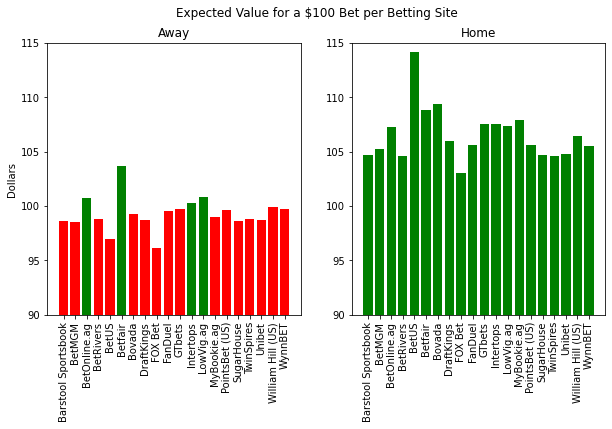

In [62]:
import matplotlib.pyplot as plt
# Plot our expected values
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
fig.suptitle('Expected Value for a $100 Bet per Betting Site')

# Make subplots to show both home and away bets
plt.subplot(1, 2, 1)

# We set bars where the expected value is less than the $100 bet would display red
# Other bets with an expected value over $100 would be green
colors_a = ['red' if avg < 100 else 'green' for avg in away_avg]
plt.bar(range(len(away_sites)), away_avg, tick_label = away_sites, color = colors_a)

# Show betting sites vertically so we can read them
plt.xticks(rotation=90)

# All values are between 90 and 115, so we want to only see that bar of each bar
plt.ylim(90, 115)
plt.title('Away')
plt.ylabel('Dollars')


# Same as above
plt.subplot(1, 2, 2)
colors_h = ['red' if avg < 100 else 'green' for avg in home_avg]
plt.bar(range(len(home_sites)),home_avg, tick_label = home_sites, color = colors_h)
plt.xticks(rotation=90)
plt.ylim(90, 115)
plt.title('Home')


plt.show()

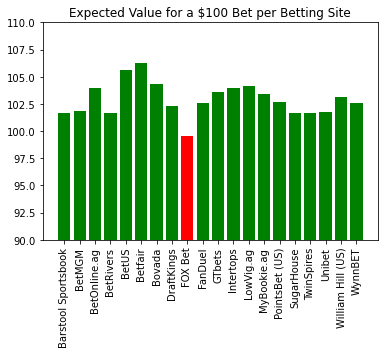

In [64]:
# Now we want to see expected value overall for a $100 Bet
overall_avg = list()
for (item1, item2) in zip(away_avg, home_avg):
    overall_avg.append((item1+item2)/2)

color_overall = ['red' if avg < 100 else 'green' for avg in overall_avg]
plt.bar(range(len(away_sites)), overall_totals, tick_label = away_sites, color = color_overall)
plt.xticks(rotation=90)
plt.ylim(90, 110)
#plt.yscale("log",base=10)
plt.title('Expected Value for a $100 Bet per Betting Site')
plt.show()

### Pretty Simple Visualization

We also created another set of visualizations that display both the home and away odds provided by each site for every single game in our dataframe. This visualization does not necessarily portray any trends within our data, but 

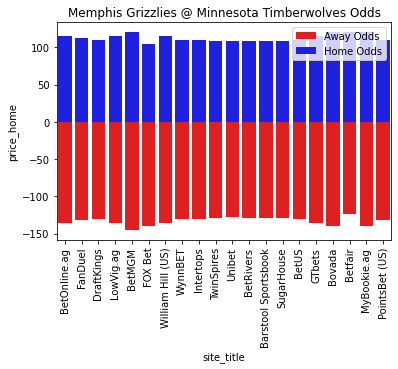

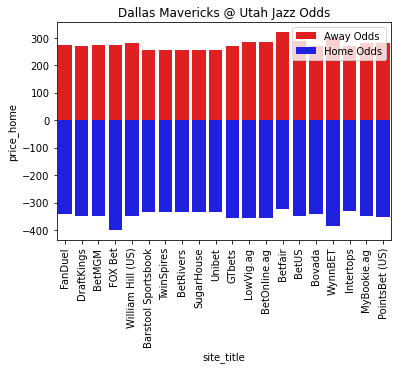

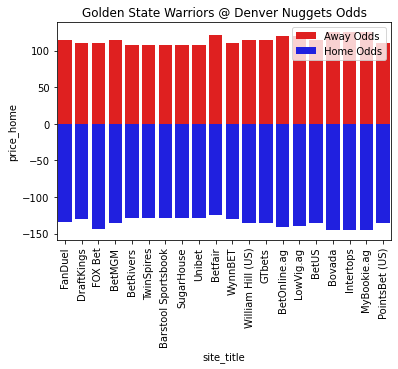

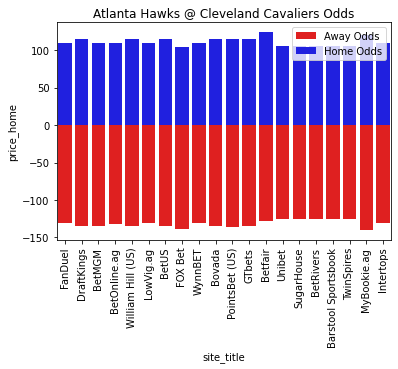

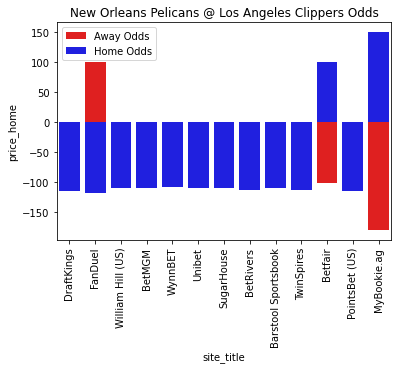

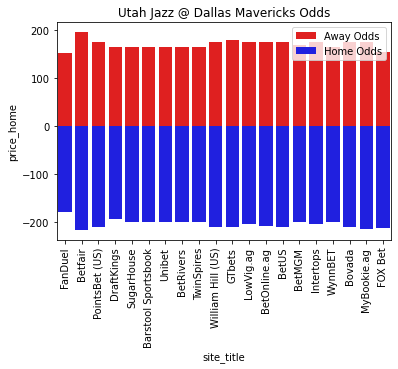

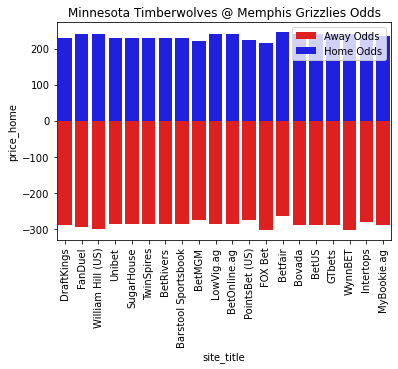

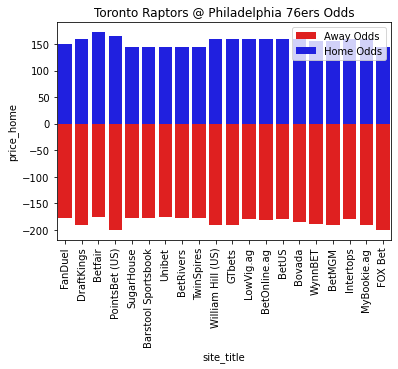

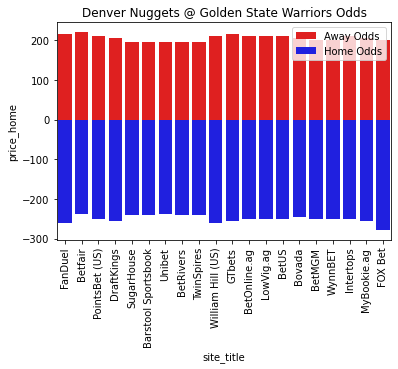

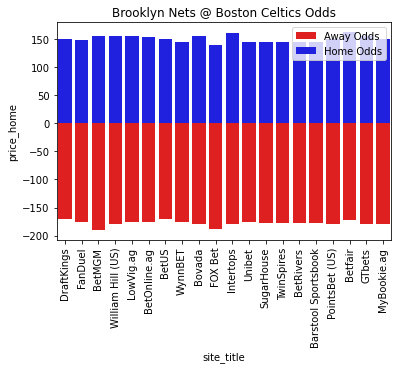

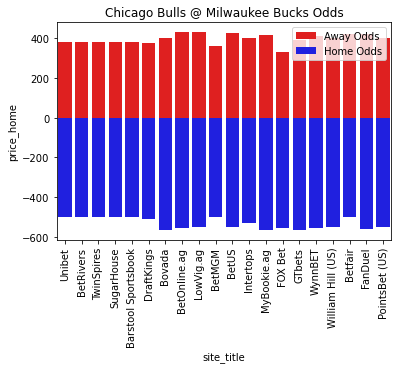

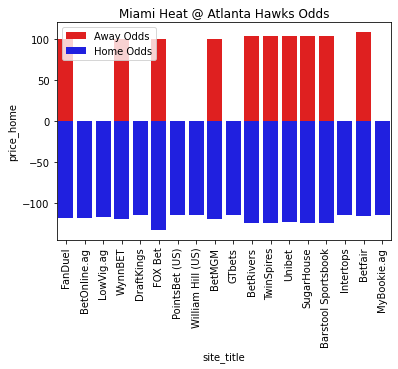

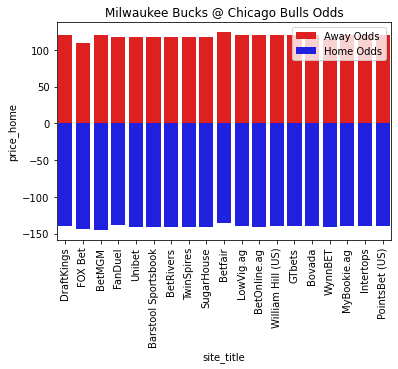

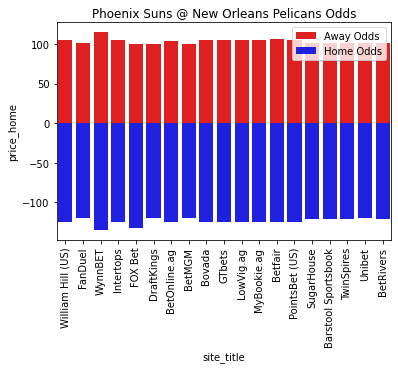

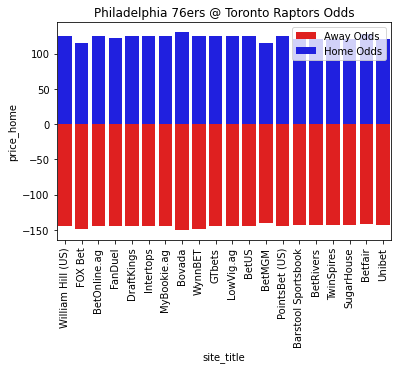

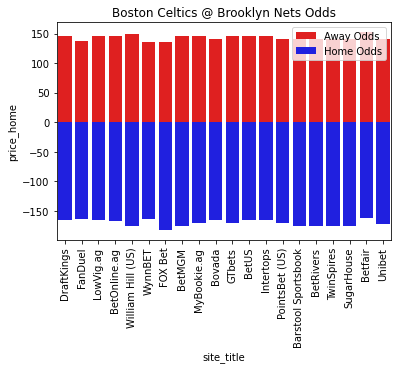

In [28]:
#Import some additional packages
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Loop through each game, so we have a nice visualization for each game
for game in games:
    # Create a new dataframe with only the game we are focusing on + extract values
    data = h2h_combined[h2h_combined['Game_ID'] == game]
    home_team_Str = data['home_team'].iloc[0]
    away_team_Str = data['away_team'].iloc[0]
    
    
    # Overlap two seaborn bar plots so we can see both the odds for home and away teams
    sns.barplot(x="site_title",y = "price_away",data= data, color = 'red', label = 'Away Odds')
    sns.barplot(x="site_title",y="price_home", data=data, color='blue', label = 'Home Odds')
    
    # Rotate x-axis labels so they can be read
    plt.xticks(rotation=90)
    
    # Title each graph so we can see the matchup
    plt.title(f'{away_team_Str} @ {home_team_Str} Odds') 
    
    # Other display options, so we can display what each color means
    plt.legend()
    plt.show()

In [67]:
h2h_combined['matchup'] = h2h_combined['away_team'] + ' @ ' + h2h_combined['home_team']
h2h_combined

,Unnamed: 0,Game_ID,away_team,bet_format,home_team,price_away,price_home,site_title,away_wins,home_wins,away_exp_value ($100 bet),home_exp_value ($100 bet),matchup
0,0,2647c9e2bee2448aff8cd9f719e18227,Memphis Grizzlies,h2h,Minnesota Timberwolves,-135.0,115.0,BetOnline.ag,56,46,94.870370,97.825000,Memphis Grizzlies @ Minnesota Timberwolves
2,2,2647c9e2bee2448aff8cd9f719e18227,Memphis Grizzlies,h2h,Minnesota Timberwolves,-132.0,112.0,FanDuel,56,46,95.787879,96.460000,Memphis Grizzlies @ Minnesota Timberwolves
4,4,2647c9e2bee2448aff8cd9f719e18227,Memphis Grizzlies,h2h,Minnesota Timberwolves,-130.0,110.0,DraftKings,56,46,96.423077,95.550000,Memphis Grizzlies @ Minnesota Timberwolves
6,6,2647c9e2bee2448aff8cd9f719e18227,Memphis Grizzlies,h2h,Minnesota Timberwolves,-135.0,115.0,LowVig.ag,56,46,94.870370,97.825000,Memphis Grizzlies @ Minnesota Timberwolves
8,8,2647c9e2bee2448aff8cd9f719e18227,Memphis Grizzlies,h2h,Minnesota Timberwolves,-145.0,120.0,BetMGM,56,46,92.086207,100.100000,Memphis Grizzlies @ Minnesota Timberwolves
...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,299,4aa919d9d10d73ab59f145c35afbf782,Chicago Bulls,h2h,Milwaukee Bucks,410.0,-556.0,WynnBET,46,51,140.250000,97.338129,Chicago Bulls @ Milwaukee Bucks
301,301,4aa919d9d10d73ab59f145c35afbf782,Chicago Bulls,h2h,Milwaukee Bucks,400.0,-550.0,William Hill (US),46,51,137.500000,97.500000,Chicago Bulls @ Milwaukee Bucks
303,303,4aa919d9d10d73ab59f145c35afbf782,Chicago Bulls,h2h,Milwaukee Bucks,420.0,-500.0,Betfair,46,51,143.000000,99.000000,Chicago Bulls @ Milwaukee Bucks
305,305,4aa919d9d10d73ab59f145c35afbf782,Chicago Bulls,h2h,Milwaukee Bucks,420.0,-560.0,FanDuel,46,51,143.000000,97.232143,Chicago Bulls @ Milwaukee Bucks


## Machine Learning: PCA Map + KMeans Clustering

Since we are comparing and looking for similarities rather than predicting, for our machine learning aspect of our project, we wanted to use K-Means Clustering to find similarities between groups of bets by clustering based off of the odds for a team with win, the probability of each team to win, and the amount of wins in the regular season to see if there is a trend amongst the bets that hit. However, as we demonstrate a little later, utilizing clustering had its shortcomings, so instead we utilized a PCA map. What inspired us to use a PCA map was that it incorporates scale normalization and removes correlations, allowing similar samples to be close together and we can observe those similar samples for trends, like which bets hit/which teams win.

In [104]:
from sklearn.decomposition import PCA
import plotly.express as px

# We want to separate away and home odds since they are stored in the same rows
x_feat_list_a = ['price_away', 'away_wins', 'away_exp_value ($100 bet)', 'away_prob']
x_feat_list_h = ['price_home', 'home_wins', 'home_exp_value ($100 bet)', 'home_prob']

# Extract the values as numpy
x_a = h2h_combined.loc[:,x_feat_list_a].to_numpy()
x_h = h2h_combined.loc[:, x_feat_list_h].to_numpy()

# Apply the PCA clustering and fit_transform
pca = PCA(n_components=2, whiten=True)
y_a = pca.fit_transform(x_a)
y_h = pca.fit_transform(x_h)


# Store our pca values in dataframe for our scatter plots
h2h_combined['pca0_a'] = y_a[:, 0]
h2h_combined['pca1_a'] = y_a[:, 1]

h2h_combined['pca0_h'] = y_h[:, 0]
h2h_combined['pca1_h'] = y_h[:, 1]

# Add hover data to make graph more interactive
hover_data_a = ['Did Away Win', 'matchup'] + x_feat_list_a
px.scatter(h2h_combined, x='pca0_a', y='pca1_a',color='Did Away Win', hover_data=hover_data_a)
fig.show()
# Save scatterplot (submitted along with report)
fig.write_html('away_clusters.html')

# Same as above
hover_data_h = ['Did Away Win', 'matchup'] + x_feat_list_h
px.scatter(h2h_combined, x='pca0_h', y='pca1_h',color='Did Away Win', hover_data=hover_data_h)
fig.show()
fig.write_html('home_clusters.html')

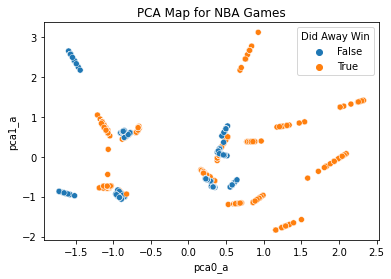

In [103]:
# Wanted to recreate the plot in seaborn so that we can see both home and away odds together

sns.scatterplot(data=h2h_combined, x='pca0_a', y='pca1_a',hue='Did Away Win')
sns.scatterplot(data=h2h_combined, x='pca0_h', y='pca1_h',hue='Did Away Win', legend=False)
plt.title('PCA Map for NBA Games')
plt.legend
plt.show()


What we can see immediately is that for each game there are many scattered points for the odds provided from each betting site. While some of this clumps of betting odds are farther apart, that's to be expected because of the way the NBA playoffs are structured. The way the NBA playoffs are structured is that teams that perform the best in the regular season and win the most games will subsequently play the weaker teams meaning that they are expected to be more greatly favored going into their matchups (i.e. a 1 seeded team playing against an 8 seeded team with be more favored to win that a 4th seeded team playing against the 5th seeded team). 

We created our PCA scatter in both seaborn and plotly, since we wanted the interactivity of plotly with the hover data, but we also wanted to compile both home and away odds into one scatterplot since we needed to extract and separate the values from each other since they were originally stored in the same row.  

The reason we decided to observe the results of a PCA map rather than going with KMeans clustering is because we simply do not have enough data points currently in our dataframe to be able to see the effects of clustering. When attempting to cluster on 4 features and scattering over 2 features, we are not able to see many notable groups of games with bets. This is because the playoffs are still in progress, we predict that as we continue to add more and more playoff games as the playoffs go on, we will be able to find superior games to bet on based on the amount of regular season wins and win probabilities of a team. 

<ipython-input-83-874e9d6956cf>:7: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



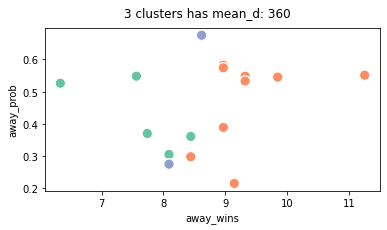

In [83]:
from sklearn.cluster import KMeans
n_clusters=3

cluster_df = h2h_combined[['price_away', 'away_wins', 'away_exp_value ($100 bet)', 'away_prob']]

# Didn't want to scale winning probability
for col in cluster_df.columns[:-1]:
    cluster_df[col] = cluster_df[col] / cluster_df[col].std()

x = cluster_df.loc[:, :].values

mean_d_dict = dict()

# fit means
kmeans = KMeans(n_clusters=n_clusters)
kmeans.fit(x)
y = kmeans.predict(x)
    
# compute & store mean distance
mean_d = -kmeans.score(x)
mean_d_dict[n_clusters] = mean_d
    
# plot clustering
plt.figure()
sns.scatterplot(data=cluster_df, x='away_wins', y='away_prob', s=100, hue=y, palette='Set2')
plt.suptitle(f'{n_clusters} clusters has mean_d: {mean_d:.0f}')
plt.gca().get_legend().remove()
plt.gcf().set_size_inches(6, 3)

## Discussion

Overall, we were able to achieve some of the objectives we set out to solve. Out first objective was to find superior/"safer" betting sites to place sporting bets on. For this, we wanted to look at the moneyline betting odds provided from multiple different sports betting sites on NBA playoff games. For this part of our project, we weren't focused on the process of choosing which team to bet on, but rather choosing the right betting site when placing bets through calculating the expected return when placing a one hundred dollar bet. What we were able to observe first of all, were that the expected return when betting on the home team seems to be higher than betting on the away team, at least for games in our dataframe. Otherwise, we see that overall Betfair has the highest expected return on a 100 dollar investment and FOXBets has the lowest. 

However, our second objective, finding better games to bet on during the NBA playoff did not return very helpful results. There are many possibilities to why we may not have gotten productive results. First of all, the NBA playoffs have started fairly recently, and we are only in the first round of games. With such a small sample size, we are not yet able to see larger trends in our data as we might in say a week or two's time. Another possibility is the unpredictability of NBA playoff games. In the playoffs, all the teams are very skilled (that's why they made it to the playoffs) and the variety of external, incalculable factors such as injuries, coach gameplans, effective shooting percentage of both teams, and of course the presence of luck all play a factor in determining what team comes out victorious on any given night.  

In the future, we would love to continue adding more and more games into our database so that our clusters can be more defined. Some other additions we want to include historical records from the past few seasons as another parameter and also give weights to star players that rank highly in the NBA as their star power also propels their team to win games. 